In [1]:
SID4 = 5330
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10
print(f"SID4={SID4} SEED={SEED} SLICE={SLICE} HP_ID={HP_ID} CLS_A={CLS_A} CLS_B={CLS_B}")

SID4=5330 SEED=5330 SLICE=330 HP_ID=2 CLS_A=0 CLS_B=3


# Assignment 6: Self Supervised and Contrastive Learning on STL10

Only SEED is used. All parts use ResNet18 with no pretrained weights.

In [2]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, models, transforms as T

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"

train = datasets.STL10("../data", split="train", download=True)
test = datasets.STL10("../data", split="test", download=True)
unl = datasets.STL10("../data", split="unlabeled", download=True)
CLASSES = train.classes

rng = np.random.default_rng(SEED)
idx = np.concatenate([rng.choice(np.where(train.labels == c)[0], 50, replace=False) for c in range(10)])
Xl, yl = torch.from_numpy(train.data[idx]), torch.from_numpy(train.labels[idx]).long()
Xt, yt = torch.from_numpy(test.data), torch.from_numpy(test.labels).long()
Xu = torch.from_numpy(unl.data)
print(len(Xl), len(Xt), len(Xu), np.bincount(yl.numpy()))

MEAN = torch.tensor([0.447, 0.440, 0.407], device=device).view(1, 3, 1, 1)
STD = torch.tensor([0.260, 0.257, 0.271], device=device).view(1, 3, 1, 1)


def prep(x):
    return (x.to(device).float() / 255 - MEAN) / STD


def encoder():
    m = models.resnet18(weights=None)
    m.fc = nn.Identity()
    return m.to(device)


def batches(n, bs, shuffle=True):
    return (torch.randperm(n) if shuffle else torch.arange(n)).split(bs)


@torch.no_grad()
def embed(net, X):
    net.eval()
    return torch.cat([net(prep(X[b])).cpu() for b in batches(len(X), 256, False)])


def linear_probe(enc, epochs=20):
    for p in enc.parameters():
        p.requires_grad = False
    Ftr, Fte = embed(enc, Xl), embed(enc, Xt)
    clf = nn.Linear(512, 10)
    opt = torch.optim.Adam(clf.parameters(), 1e-3)
    for ep in range(epochs):
        for b in batches(len(Ftr), 32):
            loss = F.cross_entropy(clf(Ftr[b]), yl[b])
            opt.zero_grad()
            loss.backward()
            opt.step()
    return (clf(Fte).argmax(1) == yt).float().mean().item()

500 8000 100000 [50 50 50 50 50 50 50 50 50 50]


## Part A: Supervised with 500 Labels

50 images per class, trained end to end for 15 epochs with random horizontal flips.

In [3]:
sup = nn.Sequential(encoder(), nn.Linear(512, 10).to(device))
opt = torch.optim.Adam(sup.parameters(), 1e-3)
for ep in range(15):
    sup.train()
    for b in batches(len(Xl), 32):
        x = prep(Xl[b])
        x = torch.where(torch.rand(len(x), 1, 1, 1, device=device) < 0.5, x.flip(3), x)
        loss = F.cross_entropy(sup(x), yl[b].to(device))
        opt.zero_grad()
        loss.backward()
        opt.step()
    print(f"epoch {ep + 1} loss {loss.item():.3f}")
acc = {"Supervised": (embed(sup, Xt).argmax(1) == yt).float().mean().item()}
print(f"Part A test accuracy: {acc['Supervised']:.4f}")

epoch 1 loss 2.244


epoch 2 loss 1.907


epoch 3 loss 2.150


epoch 4 loss 1.396


epoch 5 loss 0.935


...

epoch 12 loss 0.574


epoch 13 loss 0.364


epoch 14 loss 0.236


epoch 15 loss 0.406


Part A test accuracy: 0.3783


## Part B: Rotation Prediction

Each unlabeled image (all 100,000) gets one random rotation of 0, 90, 180 or 270 degrees per epoch. Then the rotation head is dropped, the encoder is frozen and only a linear layer is trained on the 500 labels.

In [4]:
rot = nn.Sequential(encoder(), nn.Linear(512, 4).to(device))
opt = torch.optim.Adam(rot.parameters(), 1e-3)
for ep in range(15):
    rot.train()
    correct = 0
    for b in batches(len(Xu), 256):
        x = prep(Xu[b])
        r = torch.randint(0, 4, (len(x),), device=device)
        for k in range(1, 4):
            x[r == k] = torch.rot90(x[r == k], k, (2, 3))
        out = rot(x)
        loss = F.cross_entropy(out, r)
        opt.zero_grad()
        loss.backward()
        opt.step()
        correct += (out.argmax(1) == r).sum().item()
    print(f"epoch {ep + 1} loss {loss.item():.3f} rotation acc {correct / len(Xu):.3f}")
acc["Rotation"] = linear_probe(rot[0])
print(f"Part B test accuracy: {acc['Rotation']:.4f}")

epoch 1 loss 0.826 rotation acc 0.611


epoch 2 loss 0.832 rotation acc 0.709


epoch 3 loss 0.649 rotation acc 0.748


epoch 4 loss 0.524 rotation acc 0.775


epoch 5 loss 0.550 rotation acc 0.795


...

epoch 12 loss 0.365 rotation acc 0.869


epoch 13 loss 0.366 rotation acc 0.876


epoch 14 loss 0.299 rotation acc 0.883


epoch 15 loss 0.254 rotation acc 0.890


Part B test accuracy: 0.4476


## Part C: SimCLR

20,000 unlabeled images. Two views per image from the four demo augmentations: random resized crop, horizontal flip, color jitter and random grayscale. NT Xent loss on cosine similarity with temperature 0.2 and an MLP projection head.

In [5]:
aug = T.Compose([
    T.RandomResizedCrop(96, scale=(0.2, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomApply([T.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    T.RandomGrayscale(p=0.2),
])
Xs = Xu[torch.from_numpy(rng.choice(len(Xu), 20000, replace=False))]


def nt_xent(z1, z2, tau=0.2):
    z = F.normalize(torch.cat([z1, z2]), dim=1)
    sim = (z @ z.T / tau).masked_fill(torch.eye(len(z), dtype=torch.bool, device=device), float("-inf"))
    n = len(z1)
    target = torch.cat([torch.arange(n, 2 * n), torch.arange(n)]).to(device)
    return F.cross_entropy(sim, target)


simclr = encoder()
head = nn.Sequential(nn.Linear(512, 512), nn.ReLU(), nn.Linear(512, 128)).to(device)
opt = torch.optim.Adam(list(simclr.parameters()) + list(head.parameters()), 1e-3)
for ep in range(20):
    simclr.train()
    for b in batches(len(Xs), 256):
        v1 = prep(torch.stack([aug(x) for x in Xs[b]]))
        v2 = prep(torch.stack([aug(x) for x in Xs[b]]))
        loss = nt_xent(head(simclr(v1)), head(simclr(v2)))
        opt.zero_grad()
        loss.backward()
        opt.step()
    print(f"epoch {ep + 1} loss {loss.item():.3f}")
acc["SimCLR"] = linear_probe(simclr)
print(f"Part C test accuracy: {acc['SimCLR']:.4f}")

epoch 1 loss 2.833


epoch 2 loss 2.134


epoch 3 loss 1.923


epoch 4 loss 1.859


epoch 5 loss 1.519


...

epoch 17 loss 1.137


epoch 18 loss 1.091


epoch 19 loss 1.000


epoch 20 loss 0.985


Part C test accuracy: 0.5401


## Part D: Nearest Neighbors

Test set embeddings are the 512 dimensional encoder outputs. Neighbors are ranked by cosine similarity. Precision at 5 (share of the 5 neighbors with the query's class) over all 8,000 test images is also reported.

Supervised: linear acc 0.3783, precision@5 0.3347


Rotation: linear acc 0.4476, precision@5 0.4191


SimCLR: linear acc 0.5401, precision@5 0.4720


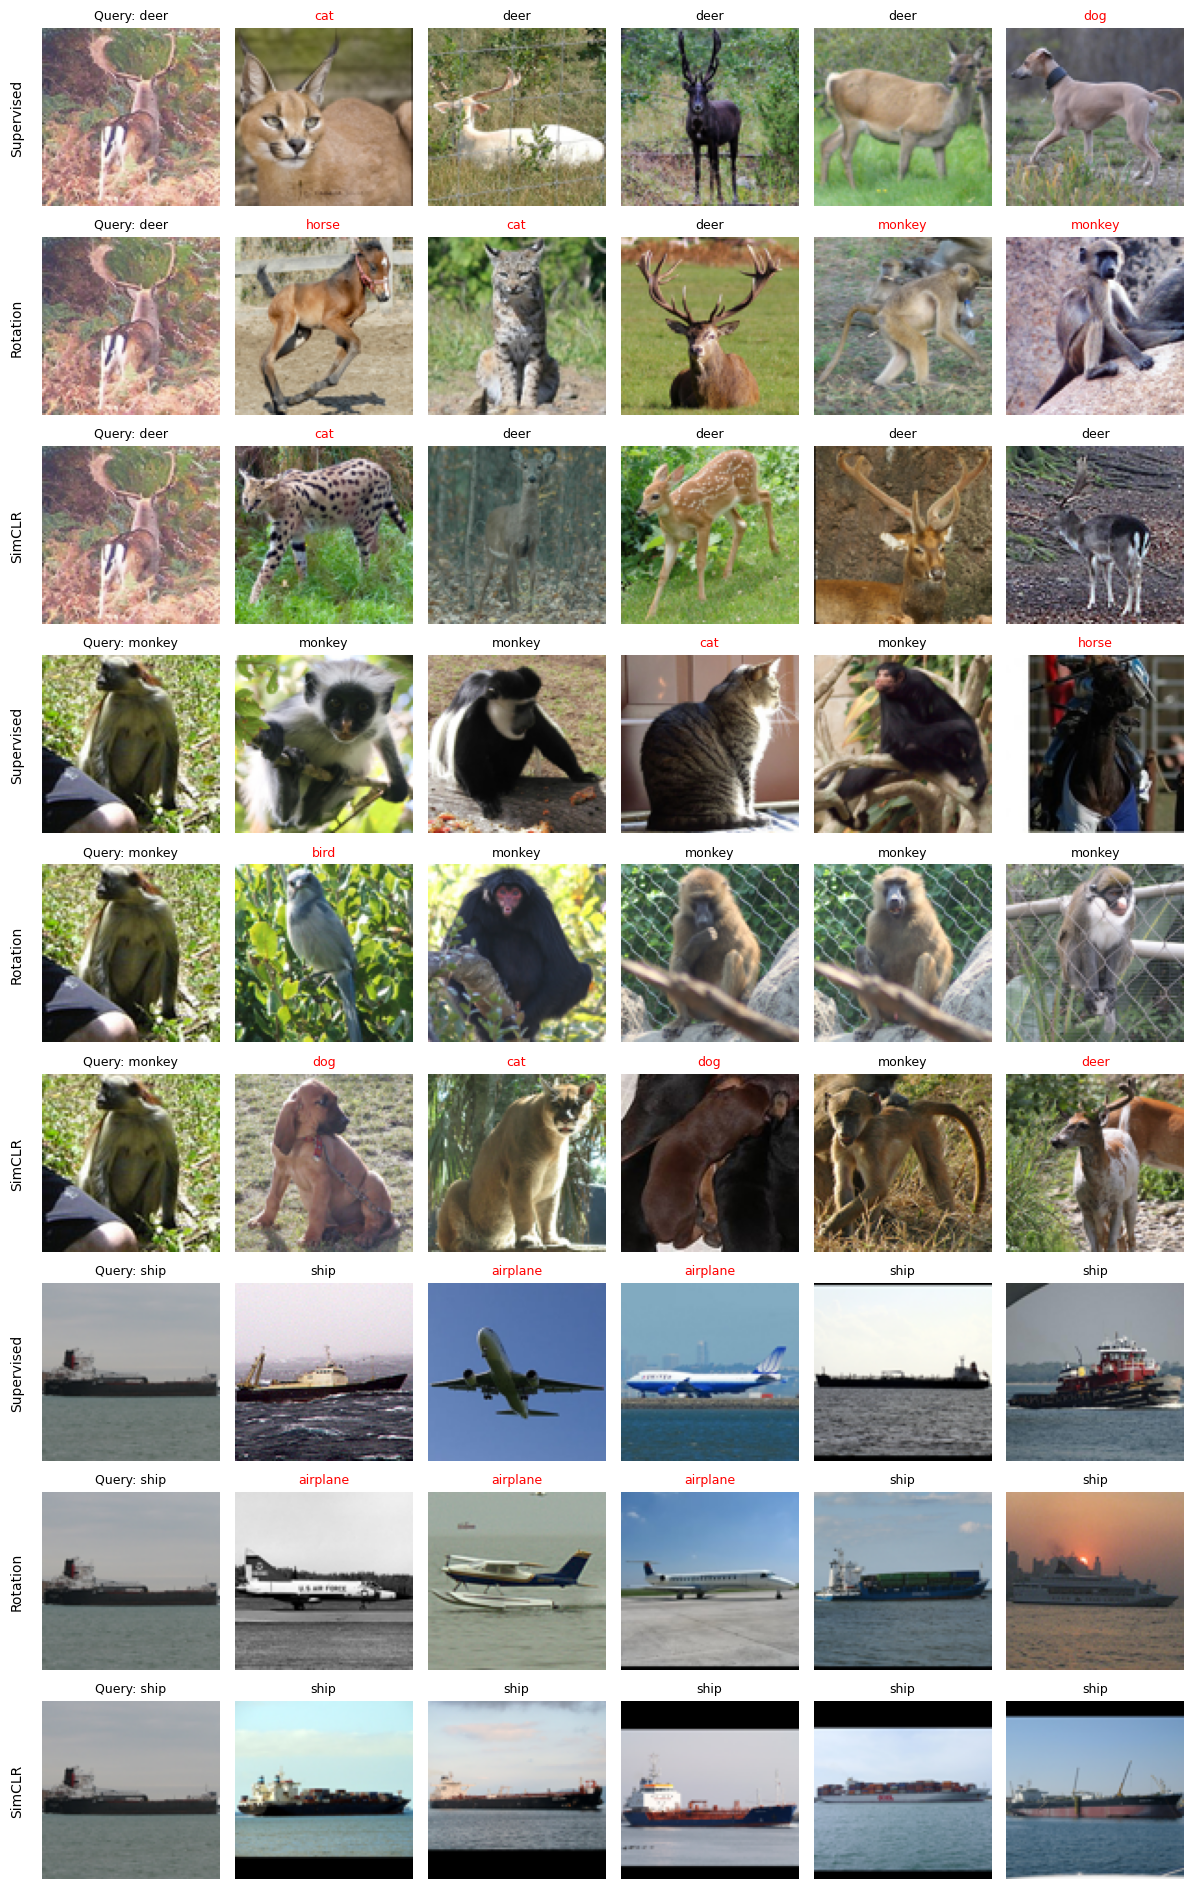

In [6]:
encoders = {"Supervised": sup[0], "Rotation": rot[0], "SimCLR": simclr}
queries = [int(rng.choice(np.where(yt.numpy() == c)[0])) for c in rng.choice(10, 3, replace=False)]
top = {}
for name, enc in encoders.items():
    E = F.normalize(embed(enc, Xt), dim=1)
    S = E @ E.T
    S.fill_diagonal_(-2)
    top[name] = S.topk(5).indices
    print(f"{name}: linear acc {acc[name]:.4f}, precision@5 {(yt[top[name]] == yt[:, None]).float().mean():.4f}")

fig, ax = plt.subplots(9, 6, figsize=(12, 19))
for i, q in enumerate(queries):
    for j, name in enumerate(encoders):
        row = ax[3 * i + j]
        for c, t in enumerate([q] + top[name][q].tolist()):
            row[c].imshow(Xt[t].permute(1, 2, 0))
            row[c].set_title(("Query: " if c == 0 else "") + CLASSES[yt[t]], fontsize=9,
                             color="black" if c == 0 or yt[t] == yt[q] else "red")
            row[c].axis("off")
        row[0].text(-10, 48, name, rotation=90, va="center", ha="right", fontsize=10)
plt.tight_layout()
plt.show()

## Analysis

| Model | Linear test accuracy | Precision at 5 |
|---|---|---|
| Supervised (Part A) | 0.3783 | 0.3347 |
| Rotation (Part B) | 0.4476 | 0.4191 |
| SimCLR (Part C) | **0.5401** | **0.4720** |

**Best model.** SimCLR performed best on both metrics. Its loss asks two augmented views of one image to match while being pushed away from every other image in the batch, so the encoder must keep features that survive cropping, flipping and color changes: object shape and parts. Those are the features that separate the ten classes, so a linear layer can read the class out of them.

**Rotation.** Predicting rotation needs some knowledge of objects (where the sky, legs or head usually are), so it beats the supervised baseline. But the task can also be solved with low level cues such as horizon lines, lighting direction and black borders, and it reached 89% rotation accuracy without needing fine class detail. Its features are therefore less class specific than SimCLR's.

**Supervised.** The supervised model saw only 500 labeled images. ResNet18 has about 11 million parameters, so it memorized the training set (loss near 0.2 to 0.4) and generalized poorly. It never used the 100,000 unlabeled images that the other two models learned from.

**Possible improvements.**
* Supervised: stronger augmentation (random crops, color jitter), weight decay, a learning rate schedule, and more epochs.
* Rotation: predict all four rotations of every image per step, train longer, and probe an earlier layer, whose features are usually more general than the last block, which specializes in rotation.
* SimCLR: train on all 100,000 images for many more epochs, use larger batches (more negatives), and add Gaussian blur. SimCLR normally trains for hundreds of epochs.
* All: a smaller stem for 96 pixel inputs (3x3 first convolution, no max pool) keeps more spatial detail.

**Nearest neighbor visualizations.** Counting correct neighbors over the three queries gives SimCLR 10 of 15, Supervised 9 and Rotation 7, matching the precision at 5 ranking across the full test set. SimCLR returned five ships for the ship query and four deer for the deer query, matching on the object itself despite changes in color and background. Rotation neighbors mostly match by layout and orientation: the ship query pulled in three airplanes with a similar horizontal shape and a horizon line. Supervised neighbors are a mix of right class and similar looking scenes (airplanes for the ship, a cat and a dog for the deer). SimCLR's weak result on the monkey query (dogs and a cat with similar brown fur) shows its features still rely partly on color and texture after only 20 epochs. Overall, SimCLR embeddings group images by semantic class best, Rotation embeddings group them by geometry and scene layout, and the Supervised embeddings are limited by having seen only 500 images.